# COMPOSITE Rule — 항 선별 + 교호작용 분석 (Shapley + PSO)

**목적함수** (정규화 ON):
$$\hat{J}(w; S) = \frac{1}{N}\sum_i \left[ \frac{Mk_i}{\text{mk\_ref}} + \frac{AQT_i}{\text{qv\_ref}} \right], \quad AQT = \frac{QV_{\text{total}}}{N_{\text{jobs}}}$$

- `mk_ref`, `qv_ref` ← `data/normalization_ref.json` (result_compare 에서 구한 observed_max)
- `qv_ref` 는 내부적으로 AQT 단위로 환산 (qv_ref_total / n_jobs)

**부분집합 가치함수**:
$$v(S) = \min_{w \in \Delta_{|S|}} \hat{J}(w; S) \quad \leftarrow \text{PSO inner-loop}$$

**산출물 (한 번의 \(2^n - 1\) 부분집합 평가에서)**
- ② elbow curve : Shapley 상위 k 누적 항으로 구성된 \(v(\text{top-}k)\)
- ③ Shapley value bar : \(\varphi_i\) (\(\varphi_i > 0\) ⇔ J 감소 기여)
- ④ Pairwise interaction heatmap : Grabisch \(I_{ij}\) (\(<0\) ⇔ 시너지, \(>0\) ⇔ 상충)

**추가적으로 쓰는 자료**
- ① 단일 항 grid (Stage 0) — "단독 강함" vs "결합 강함" 대조용 보조

**후보 항 (6개)**
`PT`, `SLACK`, `SETUP`, `C_TRANSITION`, `COMPLETION_FAST`, `WAITING`

## 1. 환경 설정 및 데이터 로드

In [1]:
import os
import sys
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

load_dotenv(os.path.join(PROJECT_ROOT, '.env'), override=True)

from utils import DataLoader
from tuning.saa_evaluator import SAAEvaluator, TRANSITION_RISK_CACHE_PATH
from tuning.composite_rule import (
    load_normalization_ref,
    DynamicCompositeEvaluator,
    single_term_screening,
    shapley_value,
    pairwise_interaction,
    cumulative_J_curve,
    estimate_cost,
)

plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

BASE_DATA_PATH = os.path.join(PROJECT_ROOT, 'data')
data = DataLoader(BASE_DATA_PATH).load_all_data()
print(f"Jobs: {len(data['jobs'])} / Operations: {len(data['operations'])} / Machines: {len(data['machines'])}")

Jobs: 60 / Operations: 870 / Machines: 60


## 2. 정규화 기준 로드 + transition risk 캐시 준비

- `mk_ref`, `qv_ref` 는 `data/normalization_ref.json` 에서 그대로 가져온다 (result_compare 의 observed_max).
- `DynamicCompositeEvaluator` 는 transition risk 테이블을 캐시 파일에서 로드한다. 캐시가 없으면 `SAAEvaluator` 를 한 번 초기화해 생성 (mk_ref/qv_ref 를 같이 넘겨 _compute_reference 건너뛰기 → 시뮬 없이 결정론적으로 끝난다).

In [2]:
NORM_REF_PATH = os.path.join(PROJECT_ROOT, 'data', 'normalization_ref.json')
MK_REF, QV_REF_AQT, NORM_RAW = load_normalization_ref(NORM_REF_PATH)
print(f"mk_ref         = {MK_REF:.3f}     ({NORM_RAW.get('mk_ref_rule')} #{NORM_RAW.get('mk_ref_try')}, observed_max)")
print(f"qv_ref (total) = {NORM_RAW['qv_ref']:.3f}     ({NORM_RAW.get('qv_ref_rule')} #{NORM_RAW.get('qv_ref_try')}, observed_max)")
print(f"qv_ref (AQT)   = {QV_REF_AQT:.3f}     (= qv_ref_total / n_jobs={NORM_RAW.get('n_jobs')})")

if not os.path.exists(TRANSITION_RISK_CACHE_PATH):
    print("\n[init] transition_risk 캐시가 없다 → SAAEvaluator 1회 초기화로 생성 (deterministic, 시뮬 없음)")
    _init = SAAEvaluator(
        data,
        obj_weights=(1.0, 1.0),
        base_seed=0,
        down_active=True,
        pm_active=False,
        mk_ref=MK_REF,
        qv_ref=QV_REF_AQT,
    )
    print(f"[init] transition_risk 생성 완료 → {TRANSITION_RISK_CACHE_PATH}")
else:
    print(f"[skip] transition_risk 캐시 존재: {TRANSITION_RISK_CACHE_PATH}")

mk_ref         = 14734.158     (random #26, observed_max)
qv_ref (total) = 68400.286     (SPTSSU #24, observed_max)
qv_ref (AQT)   = 1140.005     (= qv_ref_total / n_jobs=60)
[skip] transition_risk 캐시 존재: c:\Users\hun99\Desktop\박성현\숭실대학교\26년 4학년 1학기\전공종합논문설계\simulation_teamwork\tuning\transition_risk.json


## 3. CompositeEvaluator

- `DOWN_ACTIVE=True` 전제: stochastic 시나리오 → J_samples 분산 확보
- 재개가능 캐시(`VALUE_CACHE_PATH`)를 쓰므로 중간에 멈춰도 다시 실행하면 이어서 계산된다.

In [ ]:
DOWN_ACTIVE = True
PM_ACTIVE = False
BASE_SEED = 0

evaluator = DynamicCompositeEvaluator(
    data,
    mk_ref=MK_REF,
    qv_ref_aqt=QV_REF_AQT,
    base_seed=BASE_SEED,
    down_active=DOWN_ACTIVE,
    pm_active=PM_ACTIVE,
)
print(evaluator.summary())

# --- 후보 6항 ---
CANDIDATE_TERMS = ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
print(f"\n후보 항 ({len(CANDIDATE_TERMS)}): {CANDIDATE_TERMS}")

# --- PSO / N_RUNS 설정 ---
N_RUNS = 10
PSO_KWARGS = dict(swarm_size=4, n_iter=5, seed=0)

est = estimate_cost(len(CANDIDATE_TERMS), n_runs=N_RUNS, pso_kwargs=PSO_KWARGS, sec_per_sim=0.85)
print(f"\n[비용 견적]  total_sims = {est['sims_total']:,}    예상 소요 ≈ {est['est_hours']:.2f} h")
print(est['breakdown'].to_string(index=False))

{'mk_ref': 14734.157948534785, 'qv_ref_aqt': 1140.0047639331883, 'obj_weights': (1.0, 1.0), 'n_jobs': 60, 'down_active': True, 'pm_active': False, 'transition_risk_size': 3}

후보 항 (6): ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']

[비용 견적]  total_sims = 13,740    예상 소요 ≈ 3.24 h
 |S|  n_subsets  sims
   0          1     0
   1          6    60
   2         15  3600
   3         20  4800
   4         15  3600
   5          6  1440
   6          1   240


## 4. Stage 0 — 단일 항 grid

각 항을 단독으로 dispatch (weight=1.0) 했을 때의 J 측정. Shapley 결과와 대조해
- **단독 강함** · vs · **결합 강함** 을 구분.
- · Shapley 에서도 좋은 목적함수 값을 보이면 그냥 좋은 요소.
- · 단독에서 약했는데 Shapley 에서 좋은 지표를 보이면 조합했을때 좋은 항.

In [4]:
t0 = time.time()
single_df = single_term_screening(evaluator, CANDIDATE_TERMS, n_runs=N_RUNS, verbose=True)
print(f"\nStage 0 소요: {time.time()-t0:.1f}s")
single_df

  [1/6]               PT  J=1.3020 ± 0.0394  elapsed 9.7s
  [2/6]            SLACK  J=0.9431 ± 0.0221  elapsed 13.8s
  [3/6]            SETUP  J=1.2066 ± 0.0287  elapsed 22.4s
  [4/6]     C_TRANSITION  J=1.4469 ± 0.0350  elapsed 26.6s
  [5/6]  COMPLETION_FAST  J=1.0656 ± 0.0185  elapsed 30.6s
  [6/6]          WAITING  J=1.4712 ± 0.0376  elapsed 34.6s

Stage 0 소요: 34.6s


,term,J_hat,se,makespan_mean,aqt_mean,n_runs
0,SLACK,0.943066,0.022113,12519.733344,106.427945,10
1,COMPLETION_FAST,1.065557,0.018520,13063.201163,204.020174,10
2,SETUP,1.206611,0.028708,12201.068324,431.526349,10
3,PT,1.301974,0.039415,13044.071864,475.015928,10
4,C_TRANSITION,1.446939,0.034968,12772.736351,661.270267,10
5,WAITING,1.471160,0.037552,12871.502824,681.241652,10


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

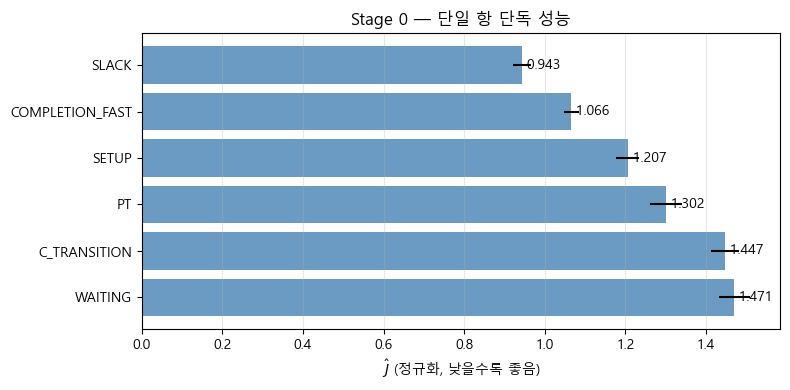

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
_df = single_df.copy().sort_values('J_hat')
ax.barh(_df['term'], _df['J_hat'], xerr=_df['se'], color='steelblue', alpha=0.8)
ax.invert_yaxis()
ax.set_xlabel(r'$\hat{J}$ (정규화, 낮을수록 좋음)')
ax.set_title('Stage 0 — 단일 항 단독 성능')
for y, (j, se) in enumerate(zip(_df['J_hat'], _df['se'])):
    ax.annotate(f' {j:.3f}', (j, y), va='center')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Stage 1 — Shapley + Pairwise Interaction + Elbow

한 번의 \(2^n - 1 = 63\) 부분집합 평가에서 ②③④ 세 가지가 공짜로 산출된다.

**재개가능 캐시**: `value_cache` 를 JSON 으로 저장/복원. 중간에 멈춰도 안전.

### 5.1 캐시 재사용 헬퍼

In [6]:
VALUE_CACHE_PATH = os.path.join(PROJECT_ROOT, 'tuning', 'value_cache.json')

def save_value_cache(cache, path=VALUE_CACHE_PATH):
    """frozenset 키 → 정렬된 항 리스트로 저장."""
    payload = {
        'meta': {
            'candidate_terms': CANDIDATE_TERMS,
            'n_runs': N_RUNS,
            'pso_kwargs': PSO_KWARGS,
            'mk_ref': MK_REF,
            'qv_ref_aqt': QV_REF_AQT,
            'base_seed': BASE_SEED,
            'down_active': DOWN_ACTIVE,
            'pm_active': PM_ACTIVE,
        },
        'entries': [
            {
                'terms': sorted(S),
                'J*': v['J*'],
                'w*': [float(x) for x in (v['w*'] if hasattr(v['w*'], '__iter__') else [])],
            }
            for S, v in cache.items()
        ],
    }
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

def load_value_cache(path=VALUE_CACHE_PATH):
    if not os.path.exists(path):
        return {}
    with open(path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    cache = {}
    for e in payload['entries']:
        cache[frozenset(e['terms'])] = {'J*': float(e['J*']), 'w*': np.array(e['w*'], dtype=float)}
    return cache

value_cache = load_value_cache()
print(f"기존 캐시 {len(value_cache)}개 로드 (완전 재계산을 원하면 value_cache = {{}} 으로 리셋)")

기존 캐시 64개 로드 (완전 재계산을 원하면 value_cache = {} 으로 리셋)


### 5.2 Shapley 계산 (2^n 부분집합 평가)

고비용 셀. 이전 컴패일되어 멈췄다면 이 셀만 다시 실행 → `value_cache` 에서 이어 계산된다.
필요시 10개 단위로 `save_value_cache(value_cache)` 를 수동 호출해 중간 저장.

In [7]:
t0 = time.time()
phi, value_cache, shap_meta = shapley_value(
    evaluator,
    CANDIDATE_TERMS,
    n_runs=N_RUNS,
    pso_kwargs=PSO_KWARGS,
    value_cache=value_cache,
    verbose=True,
)
save_value_cache(value_cache)
print(f"\nShapley 소요: {time.time()-t0:.1f}s   ({shap_meta['n_subsets']} 부분집합)")
print(f"캐시 저장: {VALUE_CACHE_PATH}")

phi_df = (pd.DataFrame({'term': list(phi.keys()), 'phi': list(phi.values())})
          .sort_values('phi', ascending=False).reset_index(drop=True))
phi_df['rank'] = phi_df.index + 1
print('\n[Shapley value 순위]  (phi > 0  ⇔  J 감소 기여)')
print(phi_df[['rank', 'term', 'phi']].to_string(index=False))

  [cache] 구버전 v(∅)=0 sentinel 감지 → FIFO baseline 으로 재평가
  [1/64] |S|=0  v(S)=1.47116  elapsed 4.0s

Shapley 소요: 4.0s   (64 부분집합)
캐시 저장: c:\Users\hun99\Desktop\박성현\숭실대학교\26년 4학년 1학기\전공종합논문설계\simulation_teamwork\tuning\value_cache.json

[Shapley value 순위]  (phi > 0  ⇔  J 감소 기여)
 rank            term       phi
    1           SLACK  0.249452
    2 COMPLETION_FAST  0.125819
    3           SETUP  0.110880
    4    C_TRANSITION  0.030406
    5              PT  0.016329
    6         WAITING -0.002294


### 5.3 ③ Shapley value bar chart

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

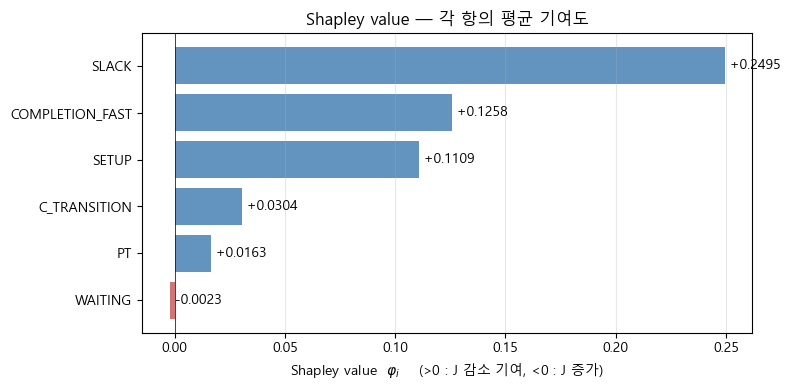

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
_df = phi_df.sort_values('phi')
colors = ['indianred' if v < 0 else 'steelblue' for v in _df['phi']]
ax.barh(_df['term'], _df['phi'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel(r'Shapley value  $\varphi_i$    (>0 : J 감소 기여, <0 : J 증가)')
ax.set_title('Shapley value — 각 항의 평균 기여도')
for y, v in enumerate(_df['phi']):
    ax.annotate(f' {v:+.4f}', (v, y), va='center')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 ④ Pairwise interaction heatmap

Grabisch interaction index \(I_{ij}\). 최소화 목적 →
- \(I_{ij} < 0\) : 같이 넣으면 J 감소가 더 크다 → **시너지**
- \(I_{ij} > 0\) : 효과 상쇄 → **상충 (대체재)**

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

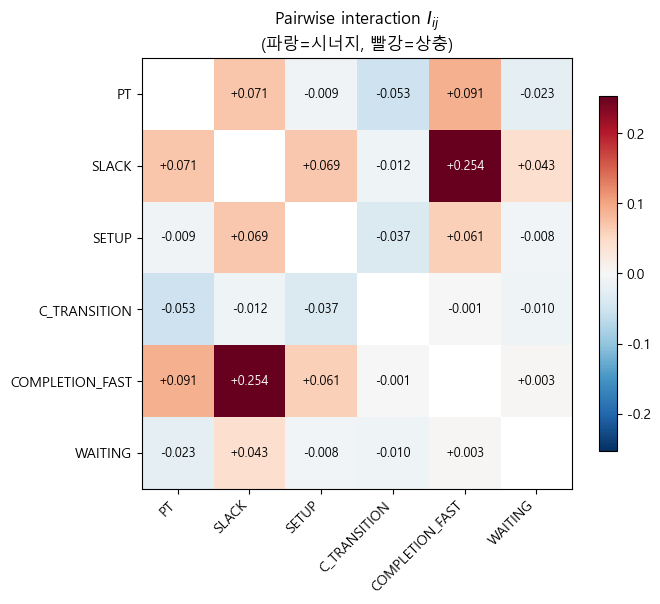


[시너지 상위 5]
           i            j      I_ij
          PT C_TRANSITION -0.052861
       SETUP C_TRANSITION -0.037063
          PT      WAITING -0.023249
       SLACK C_TRANSITION -0.011762
C_TRANSITION      WAITING -0.010156

[상충 상위 5]
    i               j     I_ij
SLACK COMPLETION_FAST 0.253528
   PT COMPLETION_FAST 0.090863
   PT           SLACK 0.070649
SLACK           SETUP 0.068868
SETUP COMPLETION_FAST 0.060690


In [9]:
inter = pairwise_interaction(value_cache, CANDIDATE_TERMS)
n = len(CANDIDATE_TERMS)
I = np.zeros((n, n))
for (a, b), v in inter.items():
    i, j = CANDIDATE_TERMS.index(a), CANDIDATE_TERMS.index(b)
    I[i, j] = v
    I[j, i] = v
np.fill_diagonal(I, np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
vmax = np.nanmax(np.abs(I))
im = ax.imshow(I, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(CANDIDATE_TERMS, rotation=45, ha='right')
ax.set_yticklabels(CANDIDATE_TERMS)
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        ax.text(j, i, f'{I[i,j]:+.3f}', ha='center', va='center',
                color='black' if abs(I[i,j]) < vmax * 0.6 else 'white', fontsize=9)
ax.set_title(r'Pairwise interaction $I_{ij}$ ' + '\n(파랑=시너지, 빨강=상충)')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

inter_df = pd.DataFrame([
    {'i': a, 'j': b, 'I_ij': v} for (a, b), v in inter.items()
]).sort_values('I_ij').reset_index(drop=True)
print('\n[시너지 상위 5]')
print(inter_df.head(5).to_string(index=False))
print('\n[상충 상위 5]')
print(inter_df.tail(5).iloc[::-1].to_string(index=False))

### 5.5 ② Elbow curve — Shapley 상위 k 누적 성능

\(\varphi\) 내림차순으로 항을 추가하면서 \(v(\text{top-}k)\) 를 그린다. 대부분 value_cache 에 이미 계산되어 있어 재사용된다 (단, 누적 top-k 가 그 항들의 부분집합과 일치 시).

이 곡선의 꺾어지는 지점이 **최적 k\* (Stage 2 의 PSO 대상 항 수)** 의 후보가 된다.

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

  k= 1  J*=0.94307  terms=['SLACK']
  k= 2  J*=0.94199  terms=['SLACK', 'COMPLETION_FAST']
  k= 3  J*=0.92649  terms=['SLACK', 'COMPLETION_FAST', 'SETUP']
  k= 4  J*=0.91618  terms=['SLACK', 'COMPLETION_FAST', 'SETUP', 'C_TRANSITION']
  k= 5  J*=0.93671  terms=['SLACK', 'COMPLETION_FAST', 'SETUP', 'C_TRANSITION', 'PT']
  k= 6  J*=0.94057  terms=['SLACK', 'COMPLETION_FAST', 'SETUP', 'C_TRANSITION', 'PT', 'WAITING']


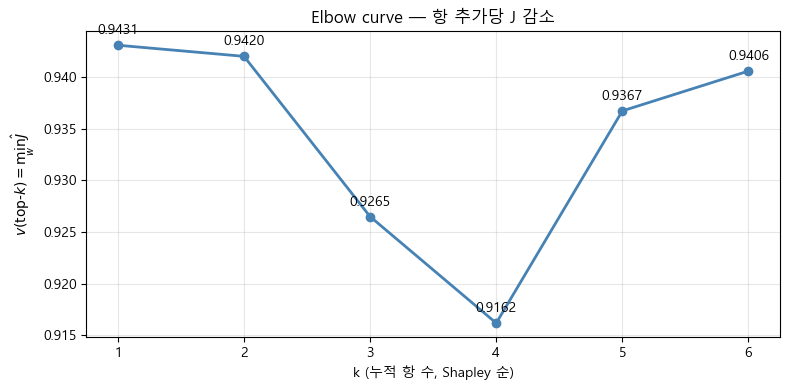


[k 추가당 감소량]
 k                                                      terms       J*   delta_J  delta_J_pct
 1                                                   (SLACK,) 0.943066  0.000000     0.000000
 2                                   (SLACK, COMPLETION_FAST) 0.941991 -0.001075    -0.113983
 3                            (SLACK, COMPLETION_FAST, SETUP) 0.926486 -0.015505    -1.645991
 4              (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION) 0.916183 -0.010303    -1.112016
 5          (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION, PT) 0.936712  0.020529     2.240734
 6 (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION, PT, WAITING) 0.940568  0.003856     0.411665


In [10]:
elbow_df = cumulative_J_curve(evaluator, phi, value_cache,
                              n_runs=N_RUNS, pso_kwargs=PSO_KWARGS, verbose=True)
save_value_cache(value_cache)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(elbow_df['k'], elbow_df['J*'], 'o-', color='steelblue', lw=2)
for k, j in zip(elbow_df['k'], elbow_df['J*']):
    ax.annotate(f'{j:.4f}', (k, j), textcoords='offset points', xytext=(0, 8), ha='center')
ax.set_xlabel('k (누적 항 수, Shapley 순)')
ax.set_ylabel(r'$v(\text{top-}k) = \min_w \hat{J}$')
ax.set_title('Elbow curve — 항 추가당 J 감소')
ax.set_xticks(elbow_df['k'])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

elbow_df['delta_J'] = elbow_df['J*'].diff().fillna(0)
elbow_df['delta_J_pct'] = (elbow_df['delta_J'] / elbow_df['J*'].shift(1)).fillna(0) * 100
print('\n[k 추가당 감소량]')
print(elbow_df[['k', 'terms', 'J*', 'delta_J', 'delta_J_pct']].to_string(index=False))

### 5.6 ②′ Interaction-adjusted Elbow — Shapley + heatmap 결합

Shapley(\(\varphi\)) 단독으로는 항 간 **pairwise redundancy** 를 못 잡는다 (예: SLACK ↔ COMPLETION_FAST \(I = +0.254\)). 매 step 마다 이미 선택된 항과의 interaction 으로 점수를 보정해 forward selection:

$$\text{adj\_score}(t \mid S) = \varphi_t - \tfrac{1}{2} \sum_{s \in S} I_{t, s}$$

(Owen-style. 계수 0.5 는 ordered marginal 평균화에서 유래.) 두 elbow 곡선을 비교해 redundancy 가 elbow 위치/값에 미치는 영향을 본다. 
value_cache 가 64개 부분집합을 모두 갖고 있어 추가 시뮬 없이 즉시 산출된다.

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

[Interaction-adjusted forward selection]
 step            pick  adj_score       phi
    1           SLACK   0.249452  0.249452
    2           SETUP   0.076446  0.110880
    3    C_TRANSITION   0.054819  0.030406
    4              PT   0.011880  0.016329
    5         WAITING  -0.002955 -0.002294
    6 COMPLETION_FAST  -0.077614  0.125819

→ adjusted order : ['SLACK', 'SETUP', 'C_TRANSITION', 'PT', 'WAITING', 'COMPLETION_FAST']
→ Shapley order  : ['SLACK', 'COMPLETION_FAST', 'SETUP', 'C_TRANSITION', 'PT', 'WAITING']


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


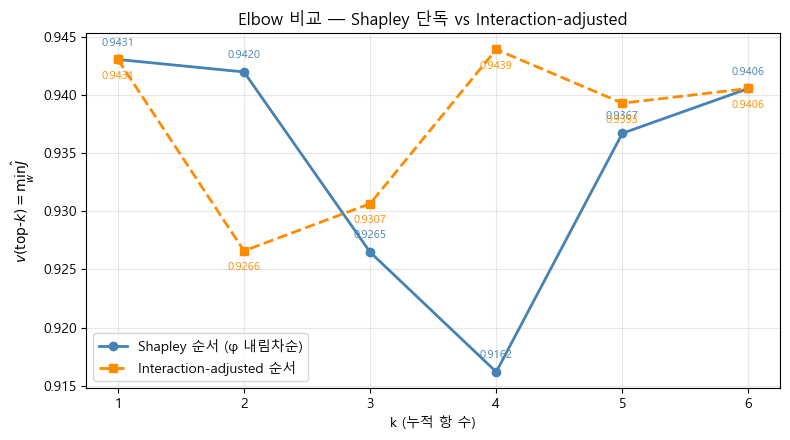


[누적 J 비교]
 k                                                 shap_terms  shap_J*                                                  adj_terms   adj_J*  delta_J (adj - shap)
 1                                                   (SLACK,) 0.943066                                                   (SLACK,) 0.943066              0.000000
 2                                   (SLACK, COMPLETION_FAST) 0.941991                                             (SLACK, SETUP) 0.926598             -0.015393
 3                            (SLACK, COMPLETION_FAST, SETUP) 0.926486                               (SLACK, SETUP, C_TRANSITION) 0.930660              0.004174
 4              (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION) 0.916183                           (SLACK, SETUP, C_TRANSITION, PT) 0.943927              0.027744
 5          (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION, PT) 0.936712                  (SLACK, SETUP, C_TRANSITION, PT, WAITING) 0.939305              0.002592
 6 (SLACK, COMPLETION_F

: 

In [ ]:
from tuning.composite_rule import value_function

def _adjusted_greedy_order(phi, inter_dict, terms):
    """φ_t - 0.5 Σ I_{t,s} 기준 forward selection."""
    selected, remaining = [], list(terms)
    trace = []
    while remaining:
        scores = {}
        for t in remaining:
            penalty = 0.0
            for s in selected:
                key = (t, s) if (t, s) in inter_dict else (s, t)
                penalty += 0.5 * inter_dict.get(key, 0.0)
            scores[t] = phi[t] - penalty
        best = max(scores, key=scores.get)
        trace.append({'step': len(selected) + 1, 'pick': best,
                      'adj_score': scores[best], 'phi': phi[best]})
        selected.append(best)
        remaining.remove(best)
    return selected, pd.DataFrame(trace)

adj_order, adj_trace = _adjusted_greedy_order(phi, inter, CANDIDATE_TERMS)
print('[Interaction-adjusted forward selection]')
print(adj_trace.to_string(index=False))
shap_order = [t for t, _ in sorted(phi.items(), key=lambda x: -x[1])]
print(f'\n→ adjusted order : {adj_order}')
print(f'→ Shapley order  : {shap_order}')

# 누적 J 곡선 — value_cache 가 흐랐으니 대수 재사용
adj_rows = []
for k in range(1, len(adj_order) + 1):
    top_k = adj_order[:k]
    S = frozenset(top_k)
    if S in value_cache:
        J_star = value_cache[S]['J*']
        w_star = value_cache[S]['w*']
    else:
        out = value_function(evaluator, top_k, N_RUNS, PSO_KWARGS)
        J_star = out['J*']; w_star = out['w*']
        value_cache[S] = out
    adj_rows.append({'k': k, 'terms': tuple(top_k), 'J*': J_star,
                     'w*': tuple(float(x) for x in w_star) if len(w_star) else ()})
adj_elbow_df = pd.DataFrame(adj_rows)
save_value_cache(value_cache)

# --- plot: 두 곡선 비교 ---
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(elbow_df['k'], elbow_df['J*'], 'o-', color='steelblue', lw=2,
        label='Shapley 순서 (φ 내림차순)')
ax.plot(adj_elbow_df['k'], adj_elbow_df['J*'], 's--', color='darkorange', lw=2,
        label='Interaction-adjusted 순서')
for k, j in zip(elbow_df['k'], elbow_df['J*']):
    ax.annotate(f'{j:.4f}', (k, j), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8, color='steelblue')
for k, j in zip(adj_elbow_df['k'], adj_elbow_df['J*']):
    ax.annotate(f'{j:.4f}', (k, j), textcoords='offset points',
                xytext=(0, -14), ha='center', fontsize=8, color='darkorange')
ax.set_xlabel('k (누적 항 수)')
ax.set_ylabel(r'$v(\text{top-}k) = \min_w \hat{J}$')
ax.set_title('Elbow 비교 — Shapley 단독 vs Interaction-adjusted')
ax.set_xticks(elbow_df['k'])
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 비교 표
cmp_df = pd.DataFrame({
    'k': elbow_df['k'].values,
    'shap_terms': elbow_df['terms'].values,
    'shap_J*': elbow_df['J*'].values,
    'adj_terms': adj_elbow_df['terms'].values,
    'adj_J*': adj_elbow_df['J*'].values,
})
cmp_df['delta_J (adj - shap)'] = cmp_df['adj_J*'] - cmp_df['shap_J*']
print('\n[누적 J 비교]')
print(cmp_df.to_string(index=False))

k_adj  = int(adj_elbow_df['J*'].idxmin()) + 1
k_shap = int(elbow_df['J*'].idxmin()) + 1
print(f'\n>>> adjusted-elbow 최소점: k={k_adj}, terms={list(adj_elbow_df.iloc[k_adj-1]["terms"])}  J*={adj_elbow_df.iloc[k_adj-1]["J*"]:.5f}')
print(f'>>> Shapley-elbow  최소점: k={k_shap}, terms={list(elbow_df.iloc[k_shap-1]["terms"])}  J*={elbow_df.iloc[k_shap-1]["J*"]:.5f}')

best_J_adj  = adj_elbow_df['J*'].min()
best_J_shap = elbow_df['J*'].min()
if best_J_adj < best_J_shap:
    print(f'\n>>> adjusted 순서가 더 낮은 J* 달성 (Δ={best_J_shap - best_J_adj:+.5f}) → redundancy 보정이 의미 있음.')
elif best_J_adj > best_J_shap:
    print(f'\n>>> Shapley 순서가 더 낮음 (Δ={best_J_adj - best_J_shap:+.5f}) → 0.5 계수가 과제일 수있음.')
else:
    print('\n>>> 두 순서의 최적 J* 같음 — redundancy 가 elbow 결정에 영향 없음.')


## 6. 요약 및 다음 단계

Stage 1 에서 산출된 세 가지 결과로부터 다음을 정리한다:

- \(\varphi_i\) : 각 항의 평균 기여도 → 항 종합 순위
- \(I_{ij}\) : 시너지/상충 쌍 → 도메인 해석
- elbow : Stage 2 의 PSO 대상 항 수 \(k^*\) 결정 후보

**Stage 2 (다음 노트북)**:
선택된 \(k^*\) 개 항 위에서 final PSO → \(w^*\), 그 다음 baseline t-test.

In [11]:
print('=== Stage 1 요약 ===')
print(f"후보 항: {CANDIDATE_TERMS}")
print(f"N_RUNS={N_RUNS}, PSO={PSO_KWARGS}, base_seed={BASE_SEED}")
print(f"정규화: mk_ref={MK_REF:.3f}, qv_ref_aqt={QV_REF_AQT:.3f}")
print(f"평가된 부분집합: {len(value_cache)} (이 {2**len(CANDIDATE_TERMS)})")

print('\n[Shapley value 순위]')
print(phi_df[['rank', 'term', 'phi']].to_string(index=False))

print('\n[Elbow]')
print(elbow_df[['k', 'terms', 'J*']].to_string(index=False))

K_HINT = int(elbow_df['J*'].idxmin()) + 1
TOP_K_TERMS = list(elbow_df.iloc[K_HINT - 1]['terms'])
print(f"\n>>> J* 최소 지점: k={K_HINT}, terms={TOP_K_TERMS}")
print('>>> 이 항 집합이 Stage 2 (최종 PSO) 의 가장 강한 후보 이다.')
print('>>> elbow 프롯 형태를 보고 꿩어진 지점 (J 감소 폭 둘서함) 을 최종 선택하라.')

=== Stage 1 요약 ===
후보 항: ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
N_RUNS=10, PSO={'swarm_size': 4, 'n_iter': 5, 'seed': 0}, base_seed=0
정규화: mk_ref=14734.158, qv_ref_aqt=1140.005
평가된 부분집합: 64 (이 64)

[Shapley value 순위]
 rank            term       phi
    1           SLACK  0.249452
    2 COMPLETION_FAST  0.125819
    3           SETUP  0.110880
    4    C_TRANSITION  0.030406
    5              PT  0.016329
    6         WAITING -0.002294

[Elbow]
 k                                                      terms       J*
 1                                                   (SLACK,) 0.943066
 2                                   (SLACK, COMPLETION_FAST) 0.941991
 3                            (SLACK, COMPLETION_FAST, SETUP) 0.926486
 4              (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION) 0.916183
 5          (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION, PT) 0.936712
 6 (SLACK, COMPLETION_FAST, SETUP, C_TRANSITION, PT, WAITING) 0.940568

>>> J* 최소 지점: k=4, t

## 7. Stage 2 — Top-k 항 위에서 final PSO → $w^*$

Stage 1 의 elbow / Shapley 결과로 정한 `TOP_K_TERMS` 위에서 **inner-loop 보다 큰 budget 의 PSO** 를 한 번 더 돌려 최종 $w^*$ 를 얻는다.

- `TOP_K_TERMS` 기본값 = Stage 1 의 elbow 최솟값 (K_HINT) — 사용자가 plot 보고 직접 덮어쓸 수 있다.
- final PSO: swarm/iter 를 inner-loop 의 약 2–3배. $v(\text{top-}k)$ 보다 더 정확한 $w^*$ 를 얻기 위함.
- 같은 부분집합 $S$ = top-k 의 inner-loop 결과는 `value_cache` 에 이미 있으므로 비교용으로 출력한다.

In [12]:
from tuning.composite_rule import pso_simplex

# 사용자가 직접 덮어쓸 수 있는 항 집합. 기본은 Stage 1 의 elbow 최솟값.
# 예) TOP_K_TERMS = ['SLACK', 'PT', 'C_TRANSITION', 'SETUP']
TOP_K_TERMS = list(elbow_df.iloc[K_HINT - 1]['terms'])
k_star = len(TOP_K_TERMS)
print(f"TOP_K_TERMS (k*={k_star}) = {TOP_K_TERMS}")

# inner-loop 보다 큰 PSO budget
FINAL_PSO = dict(swarm_size=12, n_iter=20, seed=42)
FINAL_N_RUNS = N_RUNS   # inner-loop 와 동일 seed 묶음 사용 (CRN 일치)

def _final_eval(w):
    return evaluator.evaluate(TOP_K_TERMS, w.tolist(), n_runs=FINAL_N_RUNS)['J_hat']

t0 = time.time()
pso_out = pso_simplex(_final_eval, dim=k_star, **FINAL_PSO)
elapsed_s2 = time.time() - t0

W_STAR = np.asarray(pso_out['w*'], dtype=float)
J_STAR = float(pso_out['J*'])
print(f"\nfinal PSO 소요: {elapsed_s2:.1f}s   (eval 횟수 = {(FINAL_PSO['swarm_size']) * (FINAL_PSO['n_iter']+1)})")
print(f"w* = {dict(zip(TOP_K_TERMS, [round(float(v), 4) for v in W_STAR]))}")
print(f"J* (in-sample) = {J_STAR:.5f}")

# Stage 1 inner-loop 의 같은 부분집합 v(S) 와 비교 — final PSO 가 더 낮으면 정상
S_top = frozenset(TOP_K_TERMS)
if S_top in value_cache:
    v_inner = value_cache[S_top]['J*']
    w_inner = value_cache[S_top]['w*']
    print(f"\n[참고] Stage 1 inner-loop v(top-k) = {v_inner:.5f}  (final PSO 와의 차이 = {v_inner - J_STAR:+.5f})")
    print(f"       inner w* = {dict(zip(TOP_K_TERMS, [round(float(v), 4) for v in w_inner]))}")

TOP_K_TERMS (k*=4) = ['SLACK', 'COMPLETION_FAST', 'SETUP', 'C_TRANSITION']

final PSO 소요: 1673.1s   (eval 횟수 = 252)
w* = {'SLACK': 0.4726, 'COMPLETION_FAST': 0.2649, 'SETUP': 0.2624, 'C_TRANSITION': 0.0}
J* (in-sample) = 0.89383

[참고] Stage 1 inner-loop v(top-k) = 0.91618  (final PSO 와의 차이 = +0.02235)
       inner w* = {'SLACK': 0.123, 'COMPLETION_FAST': 0.4519, 'SETUP': 0.1531, 'C_TRANSITION': 0.2721}


## 8. Stage 3 — 검증

두 부분으로 나뉜다.

- 8.1 Baseline t-test
  - 동일 CRN seed 묶음 N_TEST 회 평가, paired t-test, **Holm–Bonferroni** 보정으로 다중 비교 통제.
- 8.2 SAA bias 추정 : in-sample $v_N$ 은 일반적으로 $v^*$ 보다 낮다 (낙관적 편향).

### 8.1 Baseline paired t-test (Holm–Bonferroni)

In [13]:
from scipy import stats

N_TEST = 30
BASELINE_RULES = ['FIFO', 'SPT', 'LPT', 'MIN_QTIME', 'SPTSSU', 'random']

t0 = time.time()
J_samples = {}
print(f"[N_TEST={N_TEST} CRN — 동일 seed 묶음으로 모든 rule 평가]")

# COMPOSITE(top-k, w*) — TOP_K_TERMS 와 W_STAR 사용
res_comp = evaluator.evaluate(TOP_K_TERMS, W_STAR.tolist(), n_runs=N_TEST)
J_samples['COMPOSITE'] = res_comp['J_samples']
print(f"  COMPOSITE   J={res_comp['J_hat']:.4f} ± {res_comp['se']:.4f}   elapsed {time.time()-t0:.1f}s")

for rule in BASELINE_RULES:
    res = evaluator.evaluate_rule(rule, n_runs=N_TEST)
    J_samples[rule] = res['J_samples']
    print(f"  {rule:11s} J={res['J_hat']:.4f} ± {res['se']:.4f}   elapsed {time.time()-t0:.1f}s")

summary_rows = []
for label, js in J_samples.items():
    summary_rows.append({
        'rule': label,
        'J_mean': float(js.mean()),
        'J_se': float(js.std(ddof=1) / np.sqrt(len(js))),
    })
summary_df = pd.DataFrame(summary_rows).sort_values('J_mean').reset_index(drop=True)
summary_df[['J_mean', 'J_se']] = summary_df[['J_mean', 'J_se']].round(5)
print('\n[rule별 J 요약]')
print(summary_df.to_string(index=False))

[N_TEST=30 CRN — 동일 seed 묶음으로 모든 rule 평가]
  COMPOSITE   J=0.9198 ± 0.0128   elapsed 18.1s
  FIFO        J=1.4789 ± 0.0217   elapsed 28.1s
  SPT         J=1.3111 ± 0.0246   elapsed 51.6s
  LPT         J=1.1127 ± 0.0126   elapsed 72.7s
  MIN_QTIME   J=0.9564 ± 0.0141   elapsed 82.4s
  SPTSSU      J=1.6197 ± 0.0180   elapsed 123.2s
  random      J=1.4256 ± 0.0215   elapsed 133.1s

[rule별 J 요약]
     rule  J_mean    J_se
COMPOSITE 0.91983 0.01282
MIN_QTIME 0.95642 0.01413
      LPT 1.11271 0.01258
      SPT 1.31109 0.02464
   random 1.42556 0.02147
     FIFO 1.47892 0.02169
   SPTSSU 1.61971 0.01801


In [14]:
# --- COMPOSITE 가 각 baseline 보다 유의미하게 낮은가 (단측, < 0 가설) ---
# Holm-Bonferroni 보정: m=|baselines|.
comp = J_samples['COMPOSITE']
rows = []
for rule in BASELINE_RULES:
    diff = comp - J_samples[rule]
    if np.isclose(diff.std(ddof=1), 0.0):
        p_one = 0.0 if diff.mean() < 0 else 1.0
        t_stat = float('nan')
    else:
        t_stat, p_two = stats.ttest_rel(comp, J_samples[rule])
        p_one = p_two / 2 if t_stat < 0 else 1.0 - p_two / 2
    rows.append({
        'baseline': rule,
        'mean_diff (COMP - base)': float(diff.mean()),
        't': float(t_stat) if not np.isnan(t_stat) else None,
        'p_one_sided': float(p_one),
    })
ttest_df = pd.DataFrame(rows).sort_values('p_one_sided').reset_index(drop=True)

# Holm-Bonferroni step-down
m = len(BASELINE_RULES)
alpha = 0.05
ttest_df['holm_threshold'] = [alpha / (m - i) for i in range(m)]
# step-down: 한 번 fail 하면 그 이후 전부 fail
rejected = []
stopped = False
for i, row in ttest_df.iterrows():
    if stopped or row['p_one_sided'] > row['holm_threshold']:
        rejected.append(False); stopped = True
    else:
        rejected.append(True)
ttest_df['reject_H0 (COMP<base 유의)'] = rejected
ttest_df[['mean_diff (COMP - base)', 't', 'p_one_sided', 'holm_threshold']] = (
    ttest_df[['mean_diff (COMP - base)', 't', 'p_one_sided', 'holm_threshold']].round(6)
)
print(f'[Paired t-test  COMPOSITE vs baseline, α={alpha}, Holm-Bonferroni, m={m}]')
print(ttest_df.to_string(index=False))

n_sig = int(sum(rejected))
print(f"\n>>> COMPOSITE 가 유의미하게 우수한 baseline: {n_sig}/{m}")
if n_sig == m:
    print('>>> 모든 baseline 대비 유의미한 J 개선 — 강한 결과.')
elif n_sig >= m // 2:
    print('>>> 다수 baseline 에 유의미한 개선 — 채택 가능.')
else:
    print('>>> 일부에서만 유의 — top-k 재선택 또는 PSO budget 증가 검토.')

[Paired t-test  COMPOSITE vs baseline, α=0.05, Holm-Bonferroni, m=6]
 baseline  mean_diff (COMP - base)          t  p_one_sided  holm_threshold  reject_H0 (COMP<base 유의)
   SPTSSU                -0.699885 -52.238893     0.000000        0.008333                      True
     FIFO                -0.559092 -37.250831     0.000000        0.010000                      True
   random                -0.505737 -24.359581     0.000000        0.012500                      True
      LPT                -0.192880 -20.601328     0.000000        0.016667                      True
      SPT                -0.391262 -20.165138     0.000000        0.025000                      True
MIN_QTIME                -0.036593  -5.582845     0.000003        0.050000                      True

>>> COMPOSITE 가 유의미하게 우수한 baseline: 6/6
>>> 모든 baseline 대비 유의미한 J 개선 — 강한 결과.


### 8.2 SAA bias — In-sample vs Held-out

SAA 이론: $\hat v_N = \min_w \hat J_N(w)$ 는 진짜 $v^*$ 에 대해 **아래로 편향** (낙관적). 같은 sample 위에서 최적화 + 평가가 일어나기 때문.

**진단**: $w^*$ 를 학습에 안 쓴 **held-out seed block** 에서 다시 평가하면
- $\hat J_{\text{held}}(w^*)$ 는 $J^*(w^*)$ 의 **편향 없는** 추정
- $v_N$ (in-sample) 과의 차이 $\; v_N - \hat J_{\text{held}}(w^*) \;$ 의 **음의 크기** = in-sample optimism

비용: held-out N_BIAS 회 추가 evaluator 호출.

In [15]:
# Stage 2 / 3.1 와 disjoint 한 seed block. base_seed 를 크게 점프시키면
# evaluator._seed_list 가 다른 정수열을 산출 → CRN 학습 묶음과 겹치지 않는다.
N_BIAS = 30
BIAS_SEED_OFFSET = 10_000   # 학습에 쓴 [0..29] 와 안 겹치는 영역

orig_base = evaluator.base_seed
evaluator.base_seed = orig_base + BIAS_SEED_OFFSET
try:
    res_held = evaluator.evaluate(TOP_K_TERMS, W_STAR.tolist(), n_runs=N_BIAS)
finally:
    evaluator.base_seed = orig_base

J_in = J_STAR
J_held = res_held['J_hat']
se_held = res_held['se']
bias_est = J_in - J_held   # 음수 ⇔ in-sample 이 낙관적 (이론 부합)

print(f"[In-sample]   J* = {J_in:.5f}   (Stage 2 PSO 결과, N={FINAL_N_RUNS})")
print(f"[Held-out]    J* = {J_held:.5f} ± {se_held:.5f}   (N_BIAS={N_BIAS}, seed offset={BIAS_SEED_OFFSET})")
print(f"[Bias 추정]   J_in - J_held = {bias_est:+.5f}")
if bias_est < -3 * se_held:
    print('  → 명백한 in-sample optimism (이론과 일치). 보고서에서는 held-out J 를 함께 보고하라.')
elif bias_est < 0:
    print('  → 약한 in-sample optimism. SE 범위 내라 단정 어려움.')
else:
    print('  → in-sample 이 오히려 더 높다 (sampling noise 또는 N 부족). N_RUNS / FINAL_N_RUNS 증가 검토.')

# 95% CI of held-out
ci_lo = J_held - 1.96 * se_held
ci_hi = J_held + 1.96 * se_held
print(f"\nHeld-out 95% CI for J(w*) : [{ci_lo:.5f}, {ci_hi:.5f}]")
print('이 구간이 baseline 의 mean 보다 낮으면 (8.1 의 t-test 와 별도로) 실제 성능 우위를 시사.')

[In-sample]   J* = 0.89383   (Stage 2 PSO 결과, N=10)
[Held-out]    J* = 0.91687 ± 0.00995   (N_BIAS=30, seed offset=10000)
[Bias 추정]   J_in - J_held = -0.02304
  → 약한 in-sample optimism. SE 범위 내라 단정 어려움.

Held-out 95% CI for J(w*) : [0.89737, 0.93638]
이 구간이 baseline 의 mean 보다 낮으면 (8.1 의 t-test 와 별도로) 실제 성능 우위를 시사.


## 9. 최종 정리

Stage 1 / 2 / 3 결과를 종합해 채택 여부를 결정한다.

In [16]:
print('=' * 60)
print('COMPOSITE Rule 최종 결과')
print('=' * 60)

print(f'\n[설정]')
print(f'  후보 항       : {CANDIDATE_TERMS}')
print(f'  N_RUNS (Stage 1/2) = {N_RUNS}')
print(f'  N_TEST (Stage 3.1) = {N_TEST}')
print(f'  N_BIAS (Stage 3.2) = {N_BIAS}')
print(f'  mk_ref = {MK_REF:.3f}   qv_ref_aqt = {QV_REF_AQT:.3f}')
print(f'  DOWN_ACTIVE = {DOWN_ACTIVE}   PM_ACTIVE = {PM_ACTIVE}')

print(f'\n[Shapley 순위]')
print(phi_df[["rank", "term", "phi"]].to_string(index=False))

print(f'\n[Stage 2 채택]')
print(f'  TOP_K_TERMS (k*={k_star}) = {TOP_K_TERMS}')
print(f'  w* = {dict(zip(TOP_K_TERMS, [round(float(v), 4) for v in W_STAR]))}')
print(f'  J_in-sample   = {J_in:.5f}')
print(f'  J_held-out    = {J_held:.5f} ± {se_held:.5f}')
print(f'  bias estimate = {bias_est:+.5f}  ({"낙관적 (이론 부합)" if bias_est < 0 else "sampling noise"})')

print(f'\n[Stage 3.1 — baseline 대비 유의성, Holm-Bonferroni]')
print(ttest_df[['baseline', 'mean_diff (COMP - base)', 'p_one_sided', 'reject_H0 (COMP<base 유의)']].to_string(index=False))
n_sig = int(ttest_df['reject_H0 (COMP<base 유의)'].sum())
print(f'  유의 baseline: {n_sig}/{len(BASELINE_RULES)}')

# 결과를 디스크에 저장 (다른 노트북에서 reproducibility 위해 참조)
FINAL_RESULT_PATH = os.path.join(PROJECT_ROOT, 'tuning', 'composite_rule_result.json')
result_payload = {
    'candidate_terms': CANDIDATE_TERMS,
    'top_k_terms': TOP_K_TERMS,
    'w_star': {t: float(v) for t, v in zip(TOP_K_TERMS, W_STAR)},
    'J_in_sample': float(J_in),
    'J_held_out': float(J_held),
    'J_held_out_se': float(se_held),
    'bias_estimate': float(bias_est),
    'shapley_phi': {k: float(v) for k, v in phi.items()},
    'pairwise_interaction': {f'{a}|{b}': float(v) for (a, b), v in inter.items()},
    'config': {
        'mk_ref': MK_REF, 'qv_ref_aqt': QV_REF_AQT,
        'N_RUNS': N_RUNS, 'N_TEST': N_TEST, 'N_BIAS': N_BIAS,
        'base_seed': BASE_SEED, 'bias_seed_offset': BIAS_SEED_OFFSET,
        'down_active': DOWN_ACTIVE, 'pm_active': PM_ACTIVE,
        'pso_inner': PSO_KWARGS, 'pso_final': FINAL_PSO,
    },
    'baseline_ttest': ttest_df.to_dict(orient='records'),
    'summary_J': summary_df.to_dict(orient='records'),
}
with open(FINAL_RESULT_PATH, 'w', encoding='utf-8') as f:
    json.dump(result_payload, f, ensure_ascii=False, indent=2)
print(f'\n>>> 결과 저장: {FINAL_RESULT_PATH}')

COMPOSITE Rule 최종 결과

[설정]
  후보 항       : ['PT', 'SLACK', 'SETUP', 'C_TRANSITION', 'COMPLETION_FAST', 'WAITING']
  N_RUNS (Stage 1/2) = 10
  N_TEST (Stage 3.1) = 30
  N_BIAS (Stage 3.2) = 30
  mk_ref = 14734.158   qv_ref_aqt = 1140.005
  DOWN_ACTIVE = True   PM_ACTIVE = False

[Shapley 순위]
 rank            term       phi
    1           SLACK  0.249452
    2 COMPLETION_FAST  0.125819
    3           SETUP  0.110880
    4    C_TRANSITION  0.030406
    5              PT  0.016329
    6         WAITING -0.002294

[Stage 2 채택]
  TOP_K_TERMS (k*=4) = ['SLACK', 'COMPLETION_FAST', 'SETUP', 'C_TRANSITION']
  w* = {'SLACK': 0.4726, 'COMPLETION_FAST': 0.2649, 'SETUP': 0.2624, 'C_TRANSITION': 0.0}
  J_in-sample   = 0.89383
  J_held-out    = 0.91687 ± 0.00995
  bias estimate = -0.02304  (낙관적 (이론 부합))

[Stage 3.1 — baseline 대비 유의성, Holm-Bonferroni]
 baseline  mean_diff (COMP - base)  p_one_sided  reject_H0 (COMP<base 유의)
   SPTSSU                -0.699885     0.000000                      True
    